<a href="https://colab.research.google.com/github/Ammara-Qaisar123/Data-Science-Analytics-P1/blob/main/Data_Science_Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DevelopersHub Data Science & Analytics Internship

# Task 3: Customer Churn Prediction (Bank Customers)

## Submitted By
**Ammara Qaisar DHC-6234**

## Objective

The objective of this project is to predict whether a bank customer is likely to leave the bank (churn) using machine learning techniques.

The project includes:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Encoding
- Classification Model
- Model Evaluation
- Feature Importance
- Business Insights

In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Step 1: Load Dataset

The Churn Modelling dataset contains information about bank customers, including demographic details, account information, and whether the customer left the bank.

The dataset is loaded using the Pandas library.

In [ ]:
# Load Dataset

df = pd.read_csv("/content/drive/MyDrive/churn modelling dataset.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Step 2: Explore Dataset

Before building any machine learning model, it is important to understand the dataset.

We will inspect:

- Shape
- Columns
- Data Types
- Summary Statistics

In [ ]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names")

print(df.columns)

Shape of Dataset: (10000, 14)

Column Names
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# Step 3: Check Missing Values

Missing values can affect machine learning models.

We will check whether the dataset contains any null values.

In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


# Observation

The dataset does not contain missing values.

Therefore, no missing value treatment is required.

# Step 4: Remove Unnecessary Columns

The following columns are unique identifiers and do not contribute to prediction.

- RowNumber
- CustomerId
- Surname

In [ ]:
df.drop(
    ['RowNumber','CustomerId','Surname'],
    axis=1,
    inplace=True
)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Step 5: Exploratory Data Analysis (EDA)

EDA helps us understand customer behavior and identify patterns related to churn.

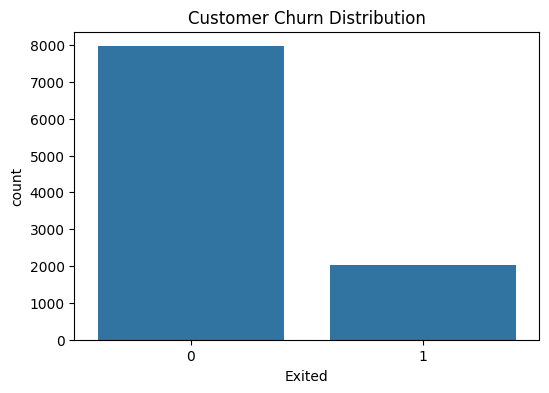

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Exited',
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

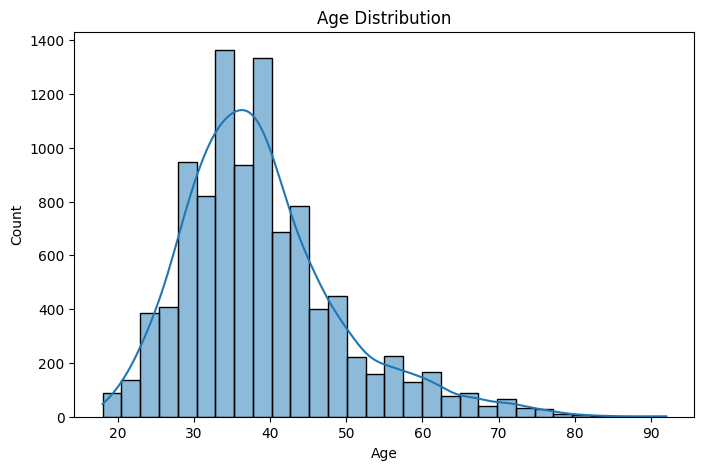

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

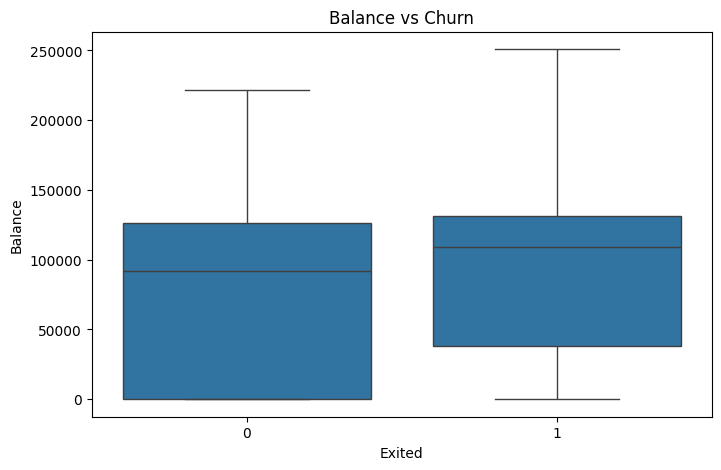

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.title("Balance vs Churn")

plt.show()

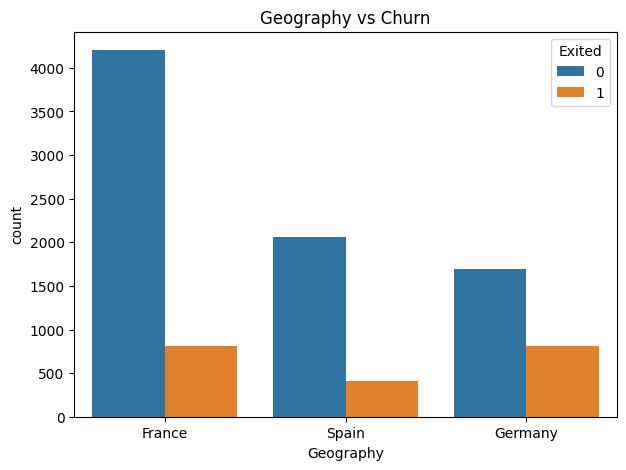

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title("Geography vs Churn")

plt.show()

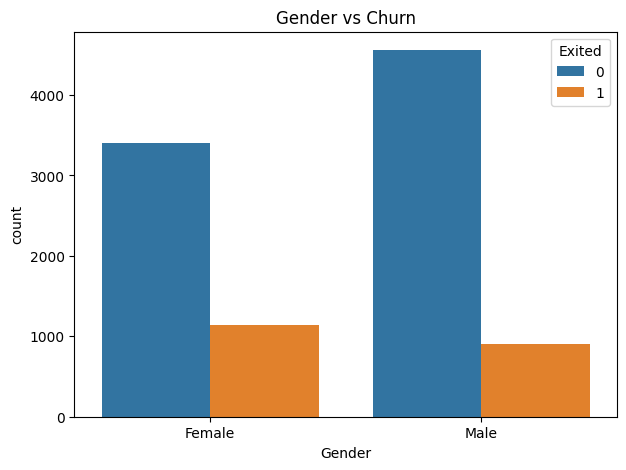

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.title("Gender vs Churn")

plt.show()

# Observation

From the above visualizations we observe:

- The majority of customers did not leave the bank.
- Older customers have a higher tendency to churn.
- Customers with higher balances appear more likely to leave.
- Churn varies across different geographical regions.

# Step 6: Encode Categorical Variables

Machine learning algorithms work with numerical data only.

The dataset contains categorical columns such as:

- Geography
- Gender

These features will be converted into numerical values using Label Encoding and One-Hot Encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# One Hot Encoding for Geography

df = pd.get_dummies(
    df,
    columns=["Geography"],
    drop_first=True
)

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


# Step 7: Define Features and Target Variable

The target variable is:

**Exited**

Features are all remaining columns.

In [ ]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

print(X.shape)

print(y.shape)

(10000, 11)
(10000,)


# Step 8: Split the Dataset

The dataset is divided into training and testing sets.

- Training Data = 80%
- Testing Data = 20%

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

# Step 9: Feature Scaling

Feature scaling standardizes the numerical values to improve the performance of machine learning algorithms such as Logistic Regression.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Step 10: Train Logistic Regression Model

Logistic Regression is one of the most commonly used algorithms for binary classification problems.

The model learns patterns from the training dataset.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Step 11: Predict Customer Churn

The trained model is used to predict whether customers are likely to leave the bank.

In [ ]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Step 12: Evaluate the Model

Model performance is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100, 2), "%")

Accuracy : 81.1 %


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[1543,   64],
       [ 314,   79]])

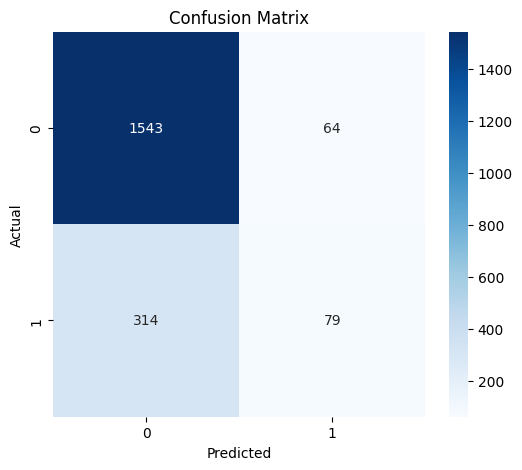

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



# Observation

The Logistic Regression model provides an initial prediction of customer churn.

The confusion matrix shows the number of correct and incorrect predictions, while the classification report summarizes precision, recall, F1-score, and overall accuracy. These metrics help assess the model's effectiveness in identifying customers who are likely to leave the bank.

# Step 13: Train Decision Tree Classifier

A Decision Tree is another supervised machine learning algorithm used for classification.

It splits the dataset into smaller subsets based on feature values to make predictions.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# Step 14: Predict Using Decision Tree

After training the model, we predict customer churn on the testing dataset.

In [ ]:
tree_pred = tree.predict(X_test)

tree_pred[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Step 15: Evaluate Decision Tree Model

The Decision Tree model is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [ ]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

print("Decision Tree Accuracy :",
      round(tree_accuracy*100,2),
      "%")

Decision Tree Accuracy : 78.4 %


In [ ]:
tree_cm = confusion_matrix(
    y_test,
    tree_pred
)

tree_cm

array([[1371,  236],
       [ 196,  197]])

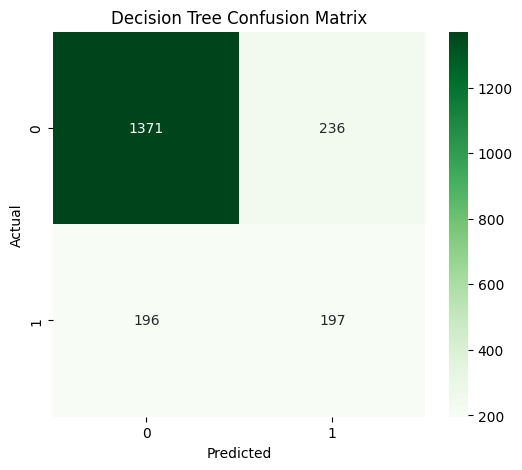

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    y_test,
    tree_pred
))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1607
           1       0.45      0.50      0.48       393

    accuracy                           0.78      2000
   macro avg       0.66      0.68      0.67      2000
weighted avg       0.79      0.78      0.79      2000



# Observation

The Decision Tree model provides another approach for predicting customer churn.

Its performance can be compared with Logistic Regression to determine which model is more suitable for this dataset.

# Step 16: Feature Importance

Feature Importance identifies which variables contribute the most to customer churn prediction.

Understanding important features helps banks improve customer retention strategies.

In [ ]:
importance = pd.Series(

    tree.feature_importances_,

    index=X.columns

)

importance.sort_values(
    ascending=False
)

,0
Age,0.223226
Balance,0.153724
EstimatedSalary,0.153710
CreditScore,0.143762
NumOfProducts,0.119747
Tenure,0.076504
IsActiveMember,0.068282
Geography_Germany,0.022055
Gender,0.014296
Geography_Spain,0.013140


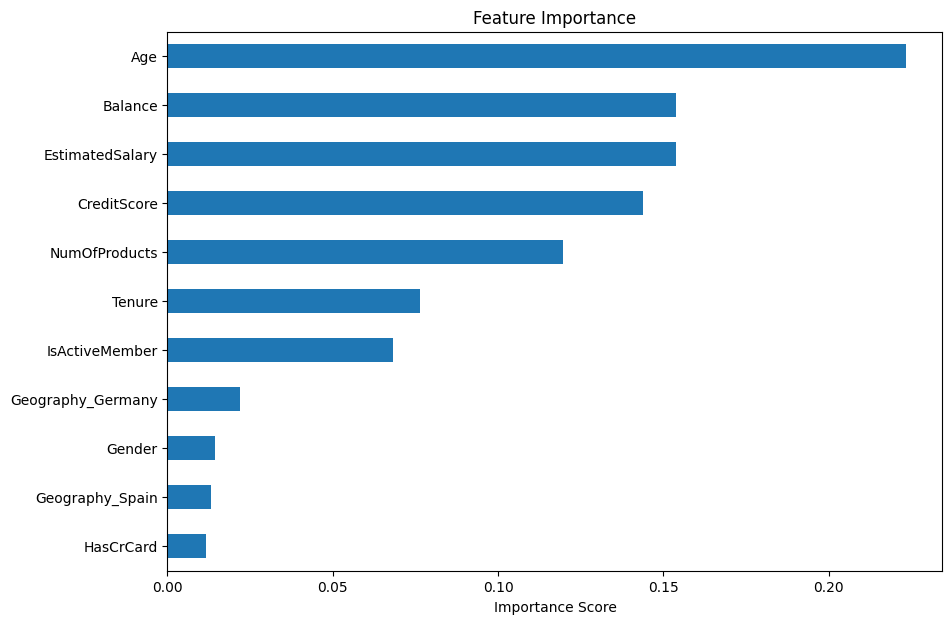

In [ ]:
plt.figure(figsize=(10,7))

importance.sort_values().plot(
    kind="barh"
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

# Observation

The Feature Importance graph highlights the variables that have the greatest influence on customer churn.

Common influential features include:

- Age
- Balance
- Number of Products
- Credit Score
- IsActiveMember
- Estimated Salary

These factors play a significant role in predicting whether a customer will leave the bank.

# Step 17: Compare the Models

The performance of both models is compared using their accuracy scores.

In [34]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        accuracy,
        tree_accuracy
    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.811
1,Decision Tree,0.784


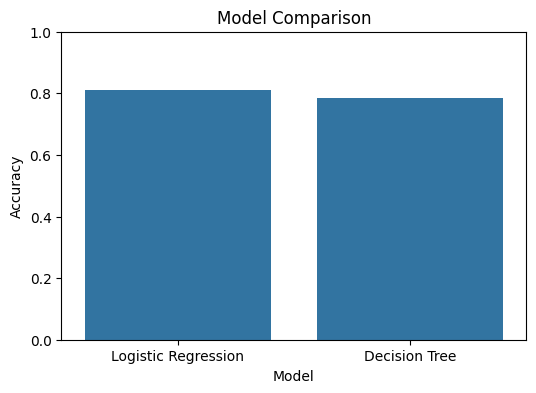

In [35]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Comparison")

plt.ylim(0,1)

plt.show()

# Business Insights

Based on the analysis:

- Older customers have a higher probability of leaving the bank.
- Customers with higher account balances tend to churn more frequently.
- Active members are less likely to leave.
- Geography influences customer retention.
- Customers with fewer banking products are more likely to churn.

These insights can help banks design personalized marketing campaigns and improve customer retention strategies.

# Conclusion

In this project, customer churn prediction was successfully performed using machine learning techniques.

The project included:

- Loading and exploring the dataset
- Data preprocessing
- Feature Encoding
- Exploratory Data Analysis (EDA)
- Logistic Regression Model
- Decision Tree Model
- Model Evaluation
- Feature Importance Analysis

Both classification models were evaluated using Accuracy, Confusion Matrix, and Classification Report.

Feature importance analysis revealed that variables such as Age, Balance, Number of Products, and Active Membership significantly influence customer churn.

This project demonstrates how machine learning can support banks in identifying customers at risk of leaving and assist in developing effective customer retention strategies.